# Tutorial 1: Getting Started with Neural Posterior Estimation (NPE)

**Course:** AI4Science — Simulation-Based Inference\
**Lecture link:** Lecture I, Part IV (Neural Posterior Estimation)

---

### Learning objectives
- Define a simulator and prior for SBI
- Train an NPE density estimator using the `sbi` package
- Sample from the learned posterior and visualise results
- Understand amortisation: infer for multiple observations without retraining

### Lecture concepts covered
- Bayes' theorem: $p(\theta | x) = p(x|\theta)p(\theta)/p(x)$
- NPE loss: $\mathcal{L} = -\mathbb{E}_{(x,\theta)\sim p(x,\theta)}[\log q_\Phi(\theta|x)]$
- Normalising flows as density estimators (Neural Spline Flows)
- Amortised inference

> **Runtime:** Select **GPU** in Colab: *Runtime → Change runtime type → T4 GPU*


## 1. Setup and Installation

In [ ]:
# Install sbi (takes ~1 min on Colab)
!pip install -q sbi torch matplotlib

import torch
import numpy as np
import matplotlib.pyplot as plt

# Check device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 460.0/460.0 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00

## 2. Define the Problem: Prior and Simulator

We start with a simple **linear Gaussian model** where the analytical posterior is known,
so we can verify that SBI recovers the correct answer.

**Model:** $x = \theta + \epsilon$, where $\epsilon \sim \mathcal{N}(0, 0.5^2 \cdot I)$

**Prior:** $\theta \sim \mathrm{Uniform}([-2, -2, -2],\; [2, 2, 2])$

This is a 3-parameter problem with 3-dimensional data.


In [ ]:
from sbi.utils import BoxUniform
from sbi.utils.user_input_checks import check_sbi_inputs, process_prior, process_simulator

num_dim = 3
noise_scale = 0.5  # We will vary this in the exercises

prior = BoxUniform(low=-2 * torch.ones(num_dim), high=2 * torch.ones(num_dim))

def simulator(theta, noise_scale=0.5):
    return theta + noise_scale * torch.randn_like(theta)

prior, num_parameters, prior_returns_numpy = process_prior(prior)
sim_fn = process_simulator(lambda theta: simulator(theta, noise_scale), prior, prior_returns_numpy)
check_sbi_inputs(sim_fn, prior)
print(f"Prior dimensionality: {num_parameters}")
print("✓ Prior and simulator are compatible with sbi")

Prior dimensionality: 3
✓ Prior and simulator are compatible with sbi


## 3. Generate Training Simulations

SBI needs pairs $(\theta^{(i)}, x^{(i)})$ drawn from the joint $p(x|\theta)p(\theta)$.
We sample parameters from the prior and run the simulator for each.


  0%|          | 0/5000 [00:00<?, ?it/s]

Parameters shape: torch.Size([5000, 3])
Data shape:       torch.Size([5000, 3])


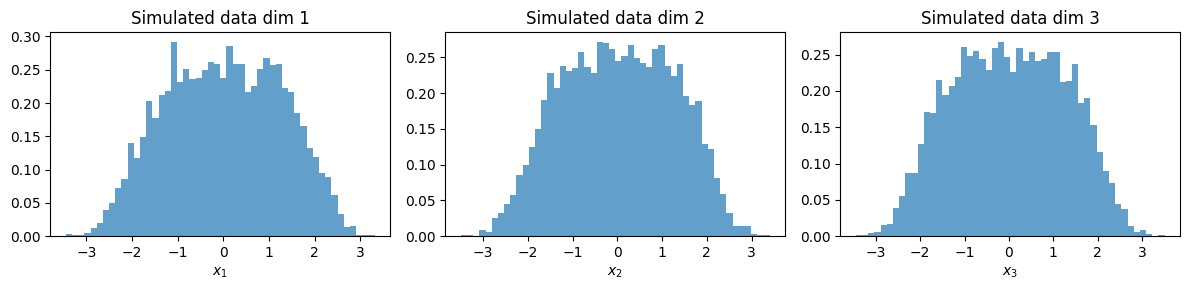

In [ ]:
from sbi.inference import simulate_for_sbi

num_simulations = 5000
theta_train, x_train = simulate_for_sbi(sim_fn, proposal=prior, num_simulations=num_simulations)
print(f"Parameters shape: {theta_train.shape}")
print(f"Data shape:       {x_train.shape}")

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for i in range(3):
    axes[i].hist(x_train[:, i].numpy(), bins=50, alpha=0.7, density=True)
    axes[i].set_xlabel(f"$x_{i+1}$")
    axes[i].set_title(f"Simulated data dim {i+1}")
plt.tight_layout(); plt.show()

## 4. Train NPE

We use **Neural Posterior Estimation** with a **Neural Spline Flow** (NSF) as the
density estimator — the architecture discussed in the lectures.


In [ ]:
from sbi.inference import NPE

# Instantiate NPE with a neural spline flow
inference = NPE(prior=prior, density_estimator="nsf")

# Append simulations and train
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train(
    training_batch_size=256,
    show_train_summary=True
)
posterior = inference.build_posterior(density_estimator)
print("\n✓ Posterior built successfully!")
print(f"Posterior type: {type(posterior).__name__}")


 Neural network successfully converged after 40 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 40
        Best validation performance: 1.5179
        -------------------------
        

✓ Posterior built successfully!
Posterior type: DirectPosterior


## 5. Perform Inference for a Specific Observation

Now we define an "observed" data point $x_o$ and sample from the posterior $q_\Phi(\theta | x_o)$.

**Key point (amortisation):** The posterior is ready for *any* $x_o$ — no retraining needed!


True parameters:   [ 0.5 -0.3  0.8]
Observed data:     [ 0.45208013 -0.22370714  0.8035702 ]


<>:24: SyntaxWarning: invalid escape sequence '\P'
<>:24: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_1113/4099518981.py:24: SyntaxWarning: invalid escape sequence '\P'
  plt.suptitle(f"Posterior $q_\Phi(\\theta | x_o)$ — red = true parameters", y=1.02)


  0%|          | 0/10000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at ../aten/src/ATen/native/BatchLinearAlgebra.cpp:2190.)
  outputs, _ = torch.triangular_solve(
/tmp/ipykernel_1113/4099518981.py:15: DeprecationWarning: you passed deprecated arguments **kwargs: ['points_colors', 'points_offdiag'], use fig_kwargs instead. We continue calling the deprecated pairplot function
  fig, axes = pairplot(


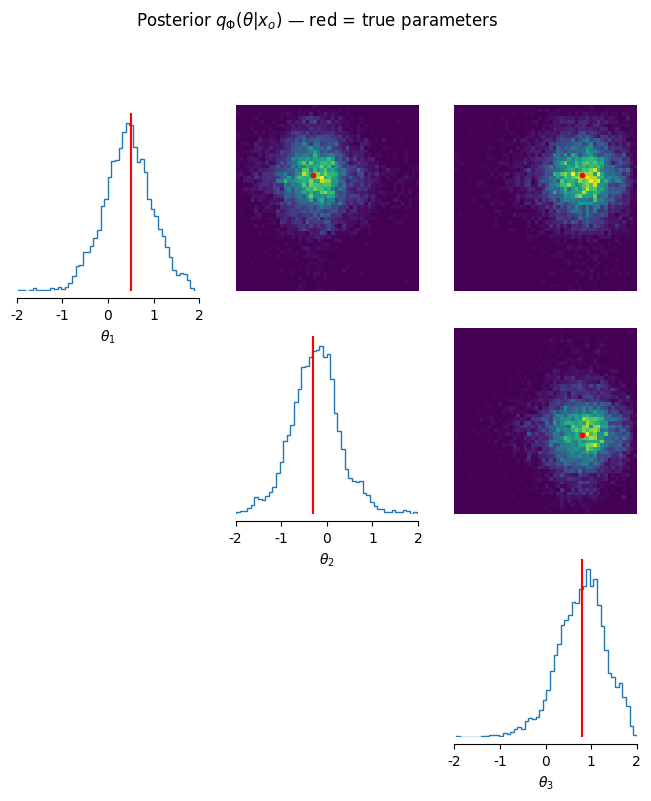

In [ ]:
from sbi.analysis import pairplot

# Define the "true" parameters and generate a synthetic observation
theta_true = torch.tensor([0.5, -0.3, 0.8])
x_o = simulator(theta_true)  # One noisy observation

print(f"True parameters:   {theta_true.numpy()}")
print(f"Observed data:     {x_o.numpy()}")

# Sample from the posterior
num_posterior_samples = 10_000
posterior_samples = posterior.sample((num_posterior_samples,), x=x_o)

# Pairplot with true values
fig, axes = pairplot(
    posterior_samples.numpy(),
    limits=[[-2, 2]] * num_dim,
    figsize=(8, 8),
    labels=[f"$\\theta_{i+1}$" for i in range(num_dim)],
    points=theta_true.numpy(),
    points_colors=["red"],
    points_offdiag={"markersize": 6}
)
plt.suptitle(f"Posterior $q_\Phi(\\theta | x_o)$ — red = true parameters", y=1.02)
plt.show()


## 6. Amortisation: Multiple Observations, Zero Retraining

One of the key advantages of NPE: we can evaluate the posterior for *different*
observations without any additional training or simulation.


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

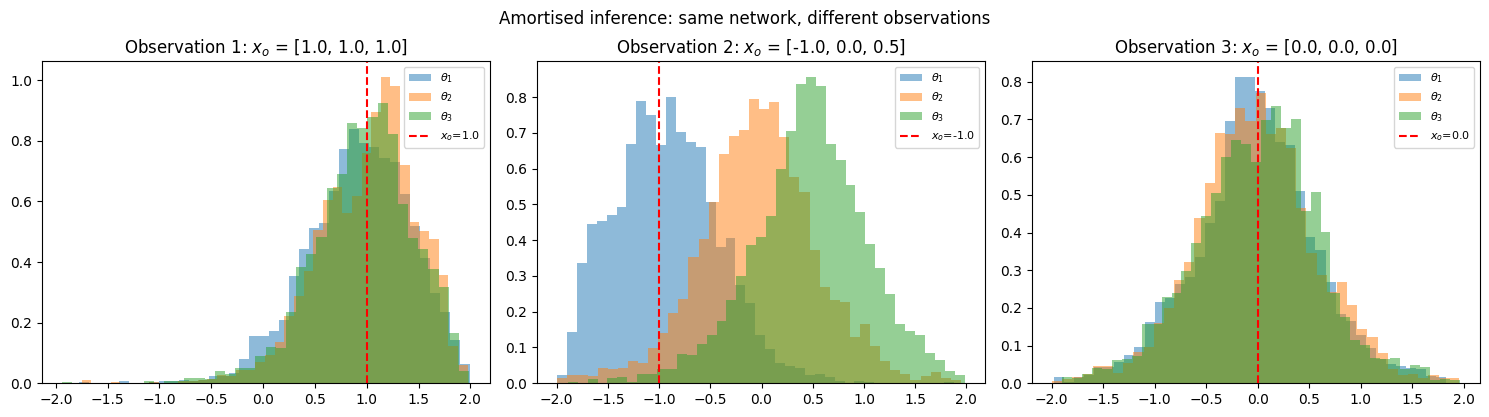

✓ All three posteriors computed with ZERO additional training!


In [ ]:
# Three different observations
observations = [
    torch.tensor([1.0, 1.0, 1.0]),
    torch.tensor([-1.0, 0.0, 0.5]),
    torch.tensor([0.0, 0.0, 0.0]),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, x_obs in enumerate(observations):
    samples = posterior.sample((5000,), x=x_obs)
    for dim in range(num_dim):
        axes[i].hist(samples[:, dim].numpy(), bins=40, alpha=0.5,
                     label=f"$\\theta_{dim+1}$", density=True)
    axes[i].axvline(x_obs[0].item(), color='red', ls='--', label=f"$x_o$={x_obs[0]:.1f}")
    axes[i].set_title(f"Observation {i+1}: $x_o$ = [{x_obs[0]:.1f}, {x_obs[1]:.1f}, {x_obs[2]:.1f}]")
    axes[i].legend(fontsize=8)
plt.tight_layout()
plt.suptitle("Amortised inference: same network, different observations", y=1.03)
plt.show()
print("✓ All three posteriors computed with ZERO additional training!")


## 7. Exercises

1. **Increase noise:** Change `noise_scale` to 1.0 or 2.0. How does the posterior width change? Why?
2. **Fewer simulations:** Reduce `num_simulations` to 500. Does the posterior quality degrade?
3. **Different density estimator:** Replace `"nsf"` with `"maf"` (Masked Autoregressive Flow). Compare training time and posterior quality.
4. **Higher dimensions:** Increase `num_dim` to 10. Does NPE still work well?

---

**Next:** Tutorial 2 compares NPE, NLE, and NRE on the same problem.



▶ Solution — Exercise 1: Effect of noise scale

Higher noise means more uncertainty in the data, so the posterior should be wider (less informative). The posterior width scales roughly with for Gaussian problems.


  0%|          | 0/5000 [00:00<?, ?it/s]

 Neural network successfully converged after 77 epochs.

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

 Neural network successfully converged after 53 epochs.

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

 Neural network successfully converged after 44 epochs.

  0%|          | 0/5000 [00:00<?, ?it/s]

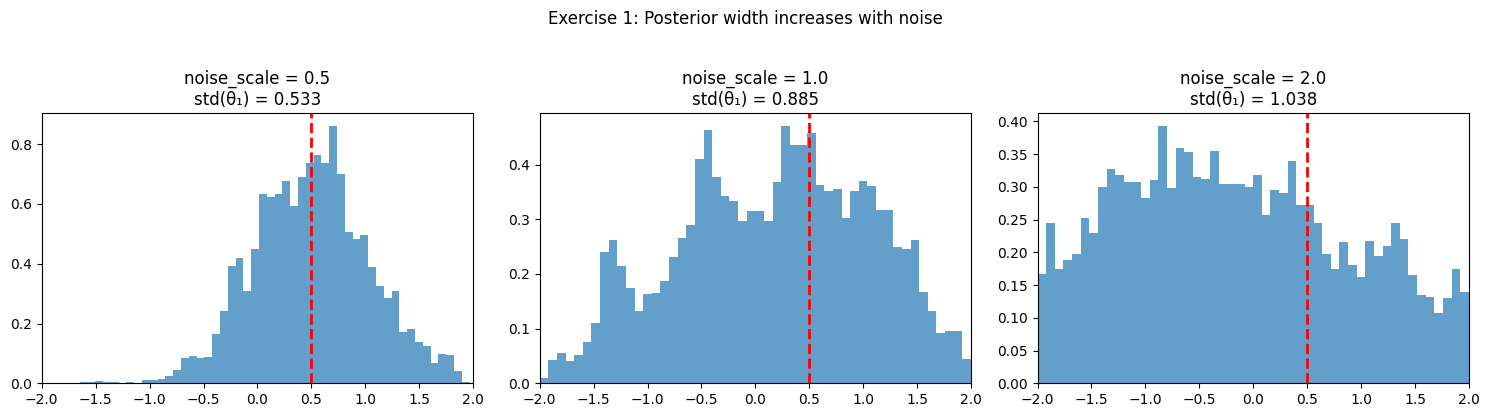

In [ ]:
# === SOLUTION: Exercise 1 — Vary noise scale ===
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
theta_true_ex = torch.tensor([0.5, -0.3, 0.8])

for idx, ns in enumerate([0.5, 1.0, 2.0]):
    # Rebuild simulator with new noise
    sim_ns = process_simulator(
        lambda theta, _ns=ns: theta + _ns * torch.randn_like(theta),
        prior, prior_returns_numpy
    )
    theta_ns, x_ns = simulate_for_sbi(sim_ns, prior, num_simulations=5000)

    inf_ns = NPE(prior, density_estimator="nsf")
    inf_ns.append_simulations(theta_ns, x_ns)
    inf_ns.train(show_train_summary=False)
    post_ns = inf_ns.build_posterior()

    x_o_ns = theta_true_ex + ns * torch.randn(num_dim)
    samples_ns = post_ns.sample((5000,), x=x_o_ns)

    ax = axes[idx]
    ax.hist(samples_ns[:, 0].numpy(), bins=50, alpha=0.7, density=True)
    ax.axvline(theta_true_ex[0].item(), color='red', ls='--', lw=2)
    ax.set_title(f"noise_scale = {ns}\nstd(θ₁) = {samples_ns[:,0].std():.3f}")
    ax.set_xlim(-2, 2)

plt.suptitle("Exercise 1: Posterior width increases with noise", y=1.03)
plt.tight_layout(); plt.show()



▶ Solution — Exercise 2: Few simulations

With only 500 simulations, the neural network has too little training data. The posterior will be poorly calibrated — it may be too wide, too narrow, or biased. This is exactly why diagnostics (Tutorial 4) are essential.


  0%|          | 0/500 [00:00<?, ?it/s]

 Neural network successfully converged after 83 epochs.

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

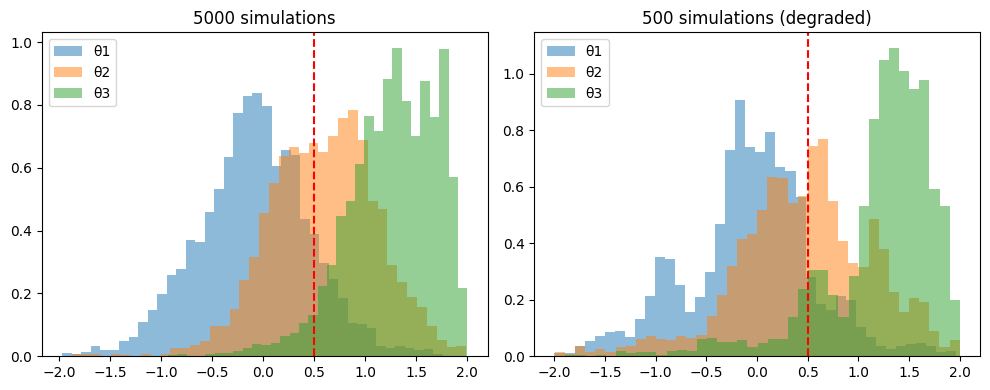

In [ ]:
# === SOLUTION: Exercise 2 — Few simulations ===
theta_few, x_few = simulate_for_sbi(sim_fn, prior, num_simulations=500)

inf_few = NPE(prior, density_estimator="nsf")
inf_few.append_simulations(theta_few, x_few)
inf_few.train(show_train_summary=False)
post_few = inf_few.build_posterior()

x_o_few = simulator(theta_true)
samples_few = post_few.sample((5000,), x=x_o_few)
samples_good = posterior.sample((5000,), x=x_o_few)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for d in range(num_dim):
    axes[0].hist(samples_good[:, d].numpy(), bins=40, alpha=0.5, density=True, label=f"θ{d+1}")
    axes[1].hist(samples_few[:, d].numpy(), bins=40, alpha=0.5, density=True, label=f"θ{d+1}")
axes[0].set_title("5000 simulations"); axes[1].set_title("500 simulations (degraded)")
for ax in axes: ax.legend(); ax.axvline(theta_true[0].item(), color='red', ls='--')
plt.tight_layout(); plt.show()


<details>
<summary><b>▶ Solution — Exercise 3: NSF vs MAF</b></summary>

MAF (Masked Autoregressive Flow) and NSF (Neural Spline Flow) differ in their elementwise transformation: MAF uses affine maps, NSF uses rational-quadratic splines. NSF is typically more expressive per layer, so it may need fewer layers for similar quality. Training time is often comparable.
</details>

In [ ]:
# === SOLUTION: Exercise 3 — NSF vs MAF ===
import time

results_arch = {}
for arch_name in ["nsf", "maf"]:
    inf_a = NPE(prior, density_estimator=arch_name)
    inf_a.append_simulations(theta_train, x_train)
    t0 = time.time()
    inf_a.train(show_train_summary=False)
    train_time = time.time() - t0
    post_a = inf_a.build_posterior()
    samp_a = post_a.sample((5000,), x=x_o)
    results_arch[arch_name] = {"time": train_time, "std": samp_a.std(dim=0).numpy()}
    print(f"{arch_name.upper():>4}: train={train_time:.1f}s, posterior std={samp_a.std(dim=0).numpy()}")


 Neural network successfully converged after 61 epochs.

  0%|          | 0/5000 [00:00<?, ?it/s]

 NSF: train=63.3s, posterior std=[0.5408731  0.51440084 0.51479864]
 Neural network successfully converged after 71 epochs.

  0%|          | 0/5000 [00:00<?, ?it/s]

 MAF: train=24.9s, posterior std=[0.4539     0.43167567 0.44473225]


<details>
<summary><b>▶ Solution — Exercise 4: Higher dimensions</b></summary>

NPE with normalising flows can handle ~10–20 parameters well. Beyond that, training becomes harder and more simulations are needed. For very high-dimensional parameter spaces, NLE or NRE with marginalisation may be preferable.
</details>

  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 74 epochs.

  0%|          | 0/3000 [00:00<?, ?it/s]

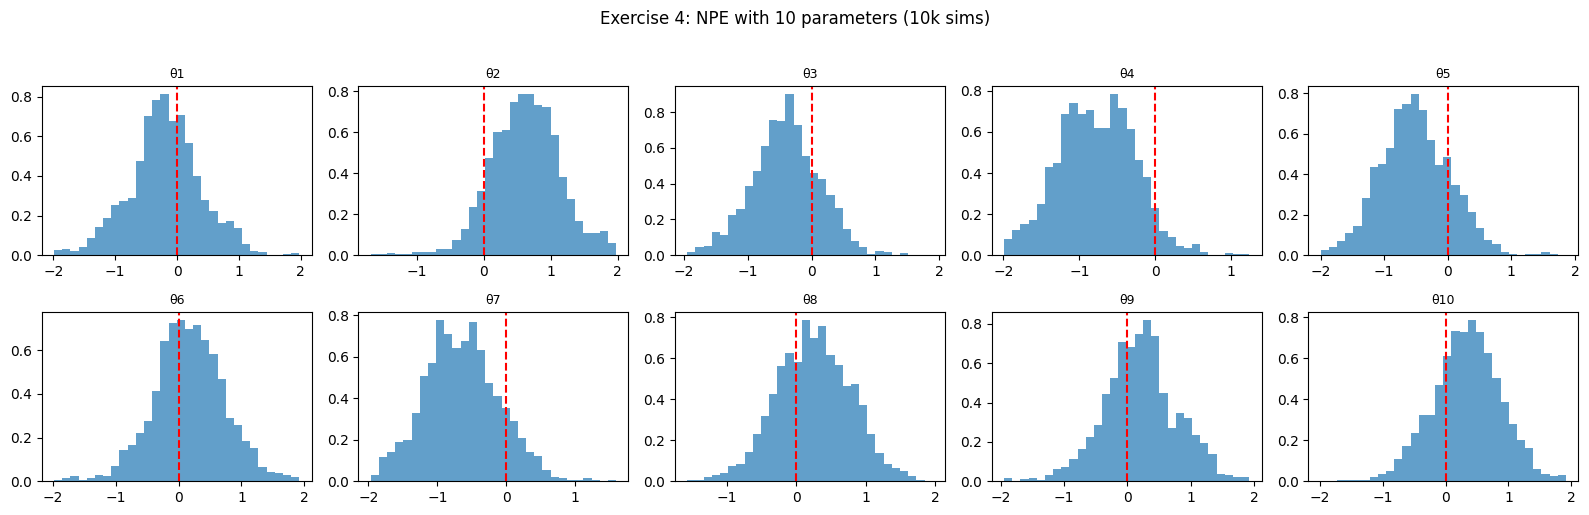

NPE handles 10D reasonably well with 10k simulations.


In [ ]:
# === SOLUTION: Exercise 4 — 10 dimensions ===
num_dim_high = 10
prior_high = BoxUniform(low=-2*torch.ones(num_dim_high), high=2*torch.ones(num_dim_high))
prior_high, _, prn = process_prior(prior_high)
sim_high = process_simulator(
    lambda theta: theta + 0.5 * torch.randn_like(theta), prior_high, prn
)

theta_h, x_h = simulate_for_sbi(sim_high, prior_high, num_simulations=10_000)
inf_h = NPE(prior_high, density_estimator="nsf")
inf_h.append_simulations(theta_h, x_h)
inf_h.train(show_train_summary=False)
post_h = inf_h.build_posterior()

theta_true_h = torch.zeros(num_dim_high)
x_o_h = theta_true_h + 0.5 * torch.randn(num_dim_high)
samples_h = post_h.sample((3000,), x=x_o_h)

fig, axes = plt.subplots(2, 5, figsize=(16, 5))
for d in range(num_dim_high):
    ax = axes[d//5][d%5]
    ax.hist(samples_h[:, d].numpy(), bins=30, density=True, alpha=0.7)
    ax.axvline(theta_true_h[d].item(), color='red', ls='--')
    ax.set_title(f"θ{d+1}", fontsize=9)
plt.suptitle("Exercise 4: NPE with 10 parameters (10k sims)", y=1.02)
plt.tight_layout(); plt.show()
print("NPE handles 10D reasonably well with 10k simulations.")
